# Проект: A/B тестирование нового алгоритма рекомендаций в развлекательном приложении

## Суть проекта:

команда разработчиков создала новый алгоритм рекомендаций для пользователей развлекательного приложения с короткими видео. По меняю разработчиков, благодаря новому алгоритму будет подбираться более интересный контент для каждого пользователя. Поэтому, мне как аналитику необходимо помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку. 




## Цели проекта
Провести A/B-тестирование нового алгоритма рекомендаций, разработанного командой, и проверить гипотезу о его способности повышать вовлечённость пользователей и улучшать ключевые метрики приложения.
## Задачи проекта
- Исследование исторических данных:
    - Анализ числа зарегистрированных пользователей и частоты их сессий;
    - Вычислить базовые метрики: среднее количество просмотров страниц за сессию, длительность сессий.
- Организация A/B-теста:
    - Формирование контрольной (A) и экспериментальной (B) групп;
    - Настройка сроков и условий проведения теста.
- Однодневный мониторинг A/B-теста:
    - Проверка корректности разделения пользователей на группы;
    - Предварительная оценка разницы в поведении пользователей.
- Анализ результатов A/B-теста:
    - Подсчет метрик (средняя длина сессии, количество просматриваемых страниц);
    - Статистическая проверка различий между группами (использование t-критерия и Z-критерия).
- Представление выводов и рекомендаций:
    - Документирование результата эксперимента;
    - Составление отчета для команды разработчиков и менеджеров продукта.

## Описание данных

Данные для исследования представлены в трех таблицах:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## План проекта:

- проведение исследования исторических данных исследуемого приложения, в том числе анализ числа регистраций и количества просмотренных страниц;
- подготовка данных к тестированию: формирование выборки, определение срока тестирования; 
- реализация мониторинга процесса A/В - тестирования за 1 день реализации работы: качества используемых данных в группе А и В, оценка размеров выборки, выявления наличия пересечений между выборками, оценка распределения данных в разрезе категориальных переменных;
- проверка результатов A/В - тестирования: подсчет метрик по выборкам и  оценка ее изменения, проведение проверки корректности результатов тестирования, проведение статистического t-теста для оценки выборок, использование z – пропорций для выявления имеет ли статистическую значимость изменение ключевой метрики.


### 1. Работа с историческими данными (EDA)

 #### 1.1. Загрузка исторических данных

In [1]:
import math
from math import ceil

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import pandas as pd

from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest

In [2]:
try: 
    sessions_history = pd.read_csv('C:/Users/Ирэн/Documents/Обучение/Data Analis_Яндекс_Практикум/Дата_сеты/AB-тестирование/sessions_project_history.csv', sep = ',')
except FileNotFoundError:
    sessions_history = pd.read_csv('/datasets/sessions_project_history.csv', sep = ',')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


Дополнительно посмотрим информаицю по датафрейму `sessions_history`.

In [4]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


Датасет `sessions_history` содержит` 435 924` строки и без пропусков. Тип данных столбцов корректен за исключением полей `session_date` и `session_start_ts`. Хотя их форматы сейчас не соответствуют типу `datetime`, исправлять это прямо сейчас не обязательно, поскольку данная операция не понадобится на начальном этапе анализа.

#### 1.2. Знакомство с данными

Найдем пользователя с максимальным количеством сессий, для того чтобы посмотреть логику формирования каждого столбца данных. 

In [5]:
result_session = sessions_history.groupby('user_id')['session_id'].nunique().idxmax()
result_session

'10E0DEFC1ABDBBE0'

In [6]:
max_user = sessions_history[sessions_history['user_id']== '10E0DEFC1ABDBBE0']
max_user.head(10)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. используя исторические данные исследуем метрику и представим ее визуализацию.

Для анализа метрики:

- рассчитаем 2 показателя в разрезе дня:
    - количество уникальных пользователей;
    - количество зарегистрированных пользователей.
- построим 2 графика отображающие динамику изменения метрик и график отображающий долю зарегистрированных пользователей от общего числа пользователе

In [7]:
registration_amount = (sessions_history.groupby(['session_date']).agg({'user_id':'nunique',
                                                            'registration_flag':'sum'}
                                                          ).rename(columns={'user_id': 'unique_amount', 
                                                                            'registration_flag': 'registration_amount'}).reset_index())

registration_amount.head()


,session_date,unique_amount,registration_amount
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840


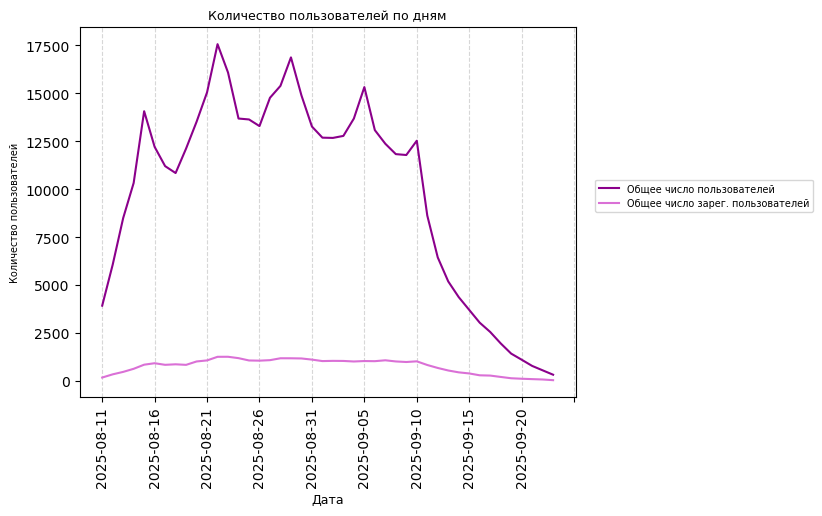

In [8]:
plt.figsize=(16,15)
#строит график для отображения общего числа пользователей
plt.plot(registration_amount['session_date'], registration_amount['unique_amount'], label = 'Общее число пользователей',color = 'darkmagenta' )

#строим график для отображения числа зарегистрированных пользователей
plt.plot(registration_amount['session_date'], registration_amount['registration_amount'], label='Общее число зарег. пользователей',color = 'orchid')

# Ограничиваем количество делений на оси X
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))  # Установите нужное значение nbins
plt.xticks(rotation=90)

# формируем дополнительные подписи и характеристи графиков
plt.title('Количество пользователей по дням',fontsize=9)
plt.xlabel('Дата',fontsize=9)
plt.ylabel('Количество пользователей',fontsize=7)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="lower left", borderaxespad=0,fontsize=7)
plt.show()

 Число зарегистрированных пользователей значительно меньше относительно общего числа пользователей. При этом есть несколько пиковых значений на графике в дневном разрезе, которые приходятся на конец рабочей недели, то есть можно предположить, что основной поток пользователей приходит перед выходными.

Далее посчитаем долю зарегистрированных пользователей и построим график отображающий динамику.

In [9]:
registration_amount['registered_ratio'] = registration_amount['registration_amount']/registration_amount['unique_amount']
registration_amount.head()

,session_date,unique_amount,registration_amount,registered_ratio
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


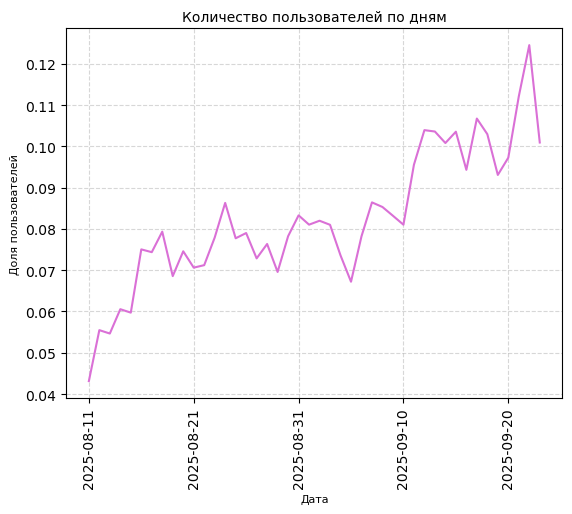

In [10]:
# Строим линию для доли зарегистрированных пользователей
registration_amount.plot.line(x='session_date', y='registered_ratio', 
                              label='Доля зарегистрированных пользователей', 
                              color='orchid', linewidth=1.5, legend = False)


# Настраиваем оси и легенду
plt.xticks(rotation=90)  # Поворачиваем метки на оси X
plt.title('Количество пользователей по дням', fontsize=10)
plt.xlabel('Дата', fontsize=8)
plt.ylabel('Доля пользователей', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)  # Прозрачная сетка

# Показываем график
plt.show()


Анализируя данные в период с 11 августа по 23 сентября 2025 года, мы наблюдаем положительная динамика роста доли зарегистрированных пользователей в приложении.  При этом стоит отметить, что были выявлены следующий паттерны:

- пиковые значения долей наблюдались в промежутке с пятницы по воскресенье;
- спад начинался в понедельник и сохранялся вплоть до следующей пятницы.

Необходимо отслеживать долгосрочные тенденции и сезонные колебания, чтобы предсказывать возможные изменения в поведении пользователей и заранее готовиться к ним.
Можно проводить A/B тесты для определения, какие элементы интерфейса привлекают больше внимания и стимулируют регистрацию в разные дни недели.


#### 1.4. Анализ числа просмотренных страниц

необходимо провести исследование метрики число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы на то, что он зарегистрируется и оплатит подписку. 

Для исследования метрики:

- найдем количество сессий для каждого значения количества просмотренных страниц;
- сформируем график для визуализации динамики изменения полученной метрики.


In [11]:
# число просмотренных страниц

amount_session = sessions_history.groupby('page_counter')['session_id'].count()
amount_session

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

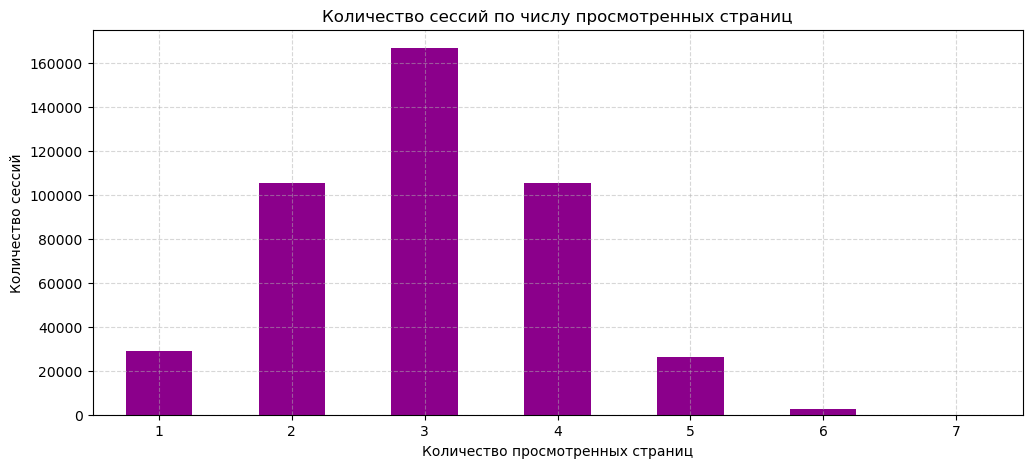

In [12]:
# строим график 
amount_session.plot( kind = 'bar',
                     title = 'Количество сессий по числу просмотренных страниц', 
                     legend = False,
                     xlabel =  'Количество просмотренных страниц',
                     ylabel = 'Количество сессий',
                     color='darkmagenta',
                     figsize=(12, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=0)


plt.show()


Согласно графику, данные визуально имеют нормальное распределение данных. однако присутствуют небольшие сдвиги вправо ("хвост"), свидетельствующий о небольшом перекосе в сторону большего числа просмотров.
Это наблюдение может говорить о следующем:
- большинство пользователей проводят умеренное количество времени в приложении, просматривая разумное число страниц.
- небольшая часть пользователей проявляет большую активность, проводя гораздо больше времени и просматривая большее количество страниц.
Такая форма распределения характерна для многих приложений и цифровых платформ, где подавляющее большинство пользователей ведут себя умеренно, а отдельные пользователи показывают значительную активность.


#### 1.5. Доля пользователей, просмотревших более четырёх страниц

Согласно данным полученным от продуктовой команды считается, если за сессию пользователь посмотрел от 4 и более страниц, то ему нравиться рекомендуемый контент. Данная метрика является прокси метрикой для продукта и ее анализ важен в рамках исследования и проведения АВ - тестирования. 

В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

Построим график со средним значением доли успешных сессий ко всем сессиям по дням за весь период наблюдения.


In [13]:
sessions_history['good_session'] = (sessions_history['page_counter']>=4).astype(int)
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [14]:
good_session_ratio = sessions_history.groupby('session_date').apply(lambda x: x['good_session'].sum()/len(x)).reset_index(name='average_good_session_rate')
good_session_ratio.head(43)

,session_date,average_good_session_rate
0,2025-08-11,0.312835
1,2025-08-12,0.302015
2,2025-08-13,0.306750
3,2025-08-14,0.316055
4,2025-08-15,0.304941
5,2025-08-16,0.306186
6,2025-08-17,0.317589
7,2025-08-18,0.310545
8,2025-08-19,0.312840
9,2025-08-20,0.306941


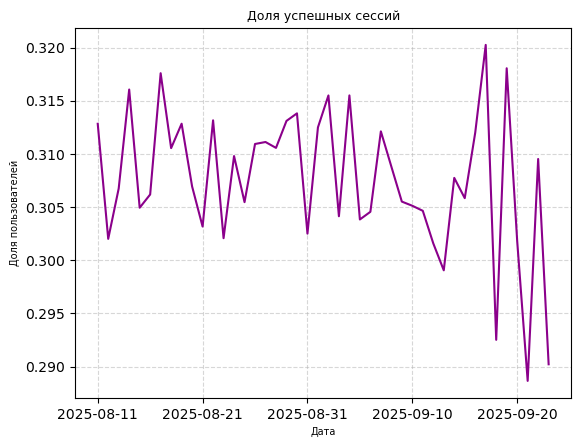

In [15]:
good_session_ratio.plot.line( x = 'session_date',
                              y = 'average_good_session_rate', 
                              color = 'darkmagenta',
                              legend = False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Доля успешных сессий',fontsize=9)
plt.xlabel('Дата',fontsize=7)
plt.ylabel('Доля пользователей',fontsize=7)

plt.show()

Согласно первоначальным данным в качестве успешной сессии считается просмотр от 4 и более страниц. Изменение доли пользователя происходит волнообразно, то есть рост и падение доли успешных сессий. При этом мы видим зависимость между долей успешных сессий и днем недели, а именно доля успешных сессий в выходные ниже, чем в будни. Это говорит нам о том, что в выходные дни пользователи проводят меньше времени в приложении или используют его менее активно, предпочитая короткие сеансы.

Рост доли пользователей в будни дни, также может говорить, что в рабочее время пользователи более целенаправленно используют приложение и взаимодействуют с контентом, причин такого роста может быть множество начиная с того, что люди «убивают» время в дороге или же кто-то использует соц.сети для работы и так далее.

Возможно, стоит адаптировать интерфейс или контент приложения под потребности пользователей в выходные дни, чтобы повысить их вовлеченность и продлить сессии. Также стоит обратить внимание на возможное увеличение рекламных предложений или персонализированных рекомендаций в выходные, чтобы привлечь внимание тех, кто проводит меньше времени в приложении.



### 2. Подготовка к  проведению АВ - тестирования

При планировании теста необходимо проделать несколько важных шагов:
- сформировать нулевую и альтернативную гипотезу;
- определить ключевую метрику;
- рассчитать необходимый размер выборки;
- исходя из текущих значений трафика, рассчитать необходимую длительность проведения теста.

####  2.1 Формирование нудевой и альтернативной гипотезы. Определение ключевой метрики

Важным этапом  перед запуском АВ- теста  являеться формирование  гипотезы. Исходя из первоначальных данных, что  команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя определим следующую нулевую и альтертнативную гипотезу:

`Нулевая гипотеза (H₀)`: новый алгоритм рекомендаций не меняет долю успешных сессий (pB <= pA).

`Альтернативная гипотеза (H₁)`: новый алгоритм увеличивает долю успешных сессий (pB > pA).

`Целевая метрика`: доля сессий пользователей просмотревших от 4 и более страниц. 

#### 2.2. Расчёт размера выборки

Проведем расчет  размера выборки  и для этого будем использовать не онлайн- калькуляторы, а расчитаем  показатель использую python.

Для этого применим  в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки мы будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.


In [16]:

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1-beta  # Мощность теста
mde = 0.03  # Минимальный детектируемый эффект

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = mde,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 17441


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения определим длительность теста, исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [17]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(sessions_history.groupby('session_date')['user_id'].nunique().mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(int(sample_size)*2/(avg_daily_users))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 4 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются. Для этого необходимо

- рассчитать количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения;

- Рассчитать и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой можно было бы увидеть возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [18]:
try: 
    sessions_test_part = pd.read_csv('C:/Users/Ирэн/Documents/Обучение/Data Analis_Яндекс_Практикум/Дата_сеты/AB-тестирование/sessions_project_test_part.csv', sep = ',')
except FileNotFoundError:
    sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv', sep = ',')

In [19]:
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


Сформируем 2 датасета для дальнешего анализа по столбцу test_group, что позволит нам исследовать данные.

In [20]:
# данные по группе А
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].reset_index()
print(f'Размер датасета group_a: {group_a.shape[0]}')

Размер датасета group_a: 1502


In [21]:
# данные по группе В
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].reset_index()
print(f'Размер датасета group_b: {group_b.shape[0]}')

Размер датасета group_b: 1628


Посчитаем количество уникальных пользователей в кажой группе.

In [22]:
unique_user_a = group_a['user_id'].nunique()
unique_user_b = group_b['user_id'].nunique()
print(f'Количество уникальных пользователей в группе А {unique_user_a}')
print(f'Количество  уникальных пользователей в группе B {unique_user_b}')

Количество уникальных пользователей в группе А 1477
Количество  уникальных пользователей в группе B 1466


In [23]:
percentage_difference = 100*(1-(unique_user_b/unique_user_a))
print(f'Процентная разницы между А и B = {percentage_difference:.4f}%')

Процентная разницы между А и B = 0.7448%


Процентная разница между уникальными данными в контрольной и тестируемой группе не значительна, поэтому, предварительно представленные выборки могут использоваться для А/В - тестирования.

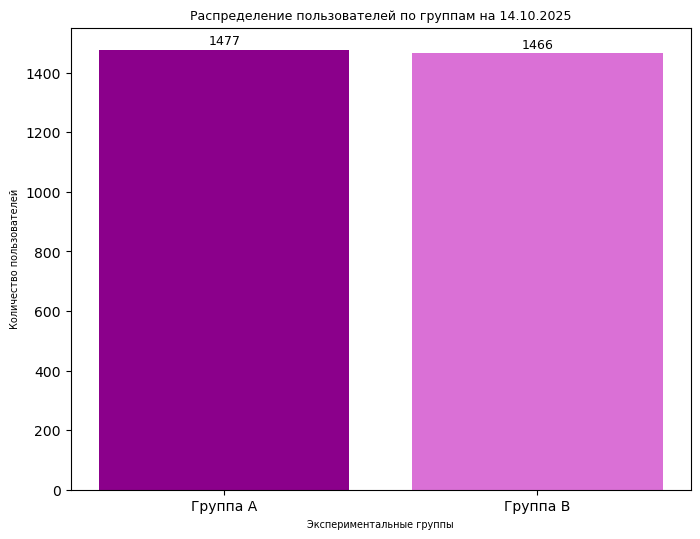

In [24]:
labels = ['Группа A', 'Группа B']
counts = [unique_user_a, unique_user_b]
colors = ['darkmagenta', 'orchid']
plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=colors)

for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', va='top', fontsize=9)
plt.title('Распределение пользователей по группам на 14.10.2025',fontsize=9)
plt.xlabel("Экспериментальные группы",fontsize=7)
plt.ylabel("Количество пользователей",fontsize=7)
plt.show()

На графике наглядно видно, что размер выборок сопоставим и разниц между данными незначительна и составляет менее 1%, соответственно далее мы можем продолжать исследование так как у нас нет перекоса в выборках.

#### 3.2. Проверка пересечений пользователей

Помимо проверки равенства количества пользователей в группах полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.


In [25]:
user_in_a = set(group_a['user_id'].unique())
user_in_b = set(group_b['user_id'].unique())

intersection_users = user_in_a.intersection(user_in_b)

if intersection_users:
    print(f"Пользователи, попавшие в обе группы: {list(intersection_users)}")
else:
    print("Никаких пользователей, встречающихся в обеих группах, не обнаружено.")


Никаких пользователей, встречающихся в обеих группах, не обнаружено.


Выборки имеют общих данных, они не зависимы что позволяет нам их использовать для дальнешего  исследования.

#### 3.3. Равномерность разделения пользователей по устройствам 

Далее проведем оценку распределения пользователей в группах в зависимости от используемого устройства , так как важно не только оценка количества пользователей в группах, но и от распределения в зависимости от качественных признаков.


In [26]:
group_device= pd.pivot_table(sessions_test_part,index=['test_group', 'device'], values='user_id', aggfunc='nunique').reset_index()


In [27]:
# расчитаем долю кажого девайса в группе.
group_device['share'] = group_device.groupby(['test_group'])['user_id'].transform(lambda x: x / x.sum())

In [28]:
group_device

,test_group,device,user_id,share
0,A,Android,656,0.444144
1,A,Mac,156,0.105619
2,A,PC,369,0.249831
3,A,iPhone,296,0.200406
4,B,Android,668,0.455662
5,B,Mac,148,0.100955
6,B,PC,381,0.259891
7,B,iPhone,269,0.183492


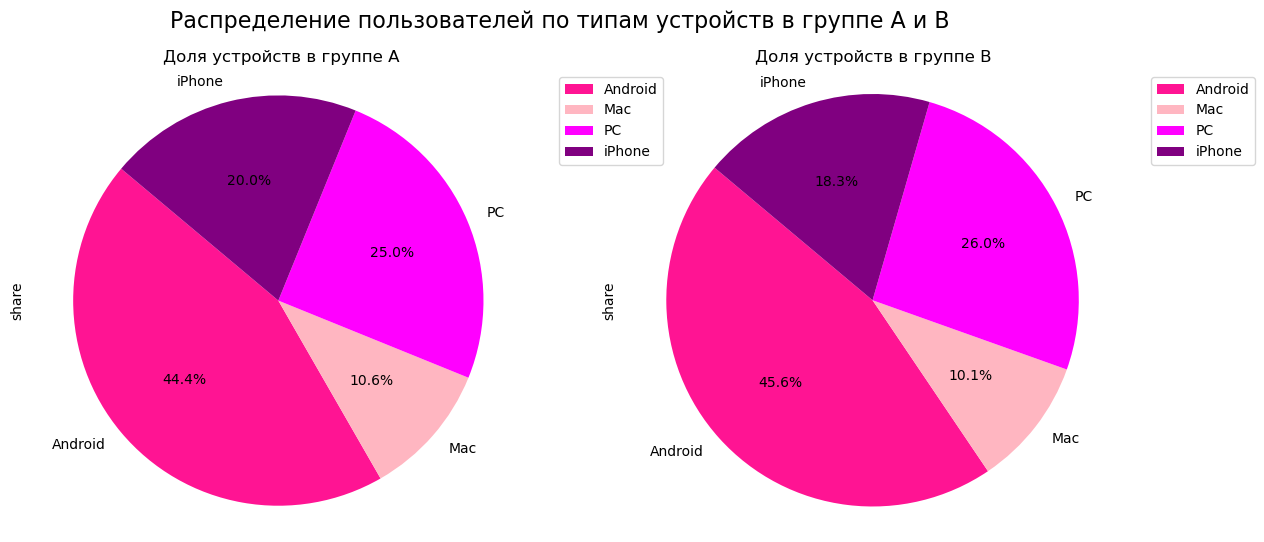

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Список цветов для каждого устройства
color = ['deeppink','lightpink', 'magenta','purple']

# формируем описание для груговой диаграммы отображающей распределение пользователей по типам устройств в группах

for idx,(name, data) in enumerate(group_device.groupby('test_group')):
    ax = axes[idx]
    data.plot(kind = 'pie', y = 'share', labels = data['device'], autopct='%1.1f%%',startangle=140,ax=ax, colors = color)
    ax.axis('equal')                             
    ax.set_title(f'Доля устройств в группе {name}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
fig.suptitle('Распределение пользователей по типам устройств в группе A и B', fontsize=16)
plt.show()

В данных представлено 4 типа устройств `iPhone`, `Android`, `PC` и `MAC`, при этом как можно заметить, что для обеих групп характерно практически равномерное распределение пользователей между устройствами, есть незначительные отличия, но они не превышают `1,7%`, то есть можно говорить, что по такой категориальной переменной как тип устройства пользователи распределены равномерно.

#### 3.4. Равномерность распределения пользователей по регионам

Проведем аналогичное исследование как в п.3.3, но в разрезе регионов.


In [30]:
# расчитаем долю кажого девайса в группе.
group_region = pd.pivot_table(sessions_test_part, index = ['test_group', 'region'], values = 'user_id',aggfunc = 'nunique').reset_index()

#рассчитываем доли 
group_region['share'] = group_region.groupby('test_group')['user_id'].transform(lambda x: x/x.sum())

In [31]:
group_region

,test_group,region,user_id,share
0,A,CIS,644,0.436019
1,A,EU,224,0.151659
2,A,MENA,609,0.412322
3,B,CIS,645,0.439973
4,B,EU,217,0.148022
5,B,MENA,604,0.412005


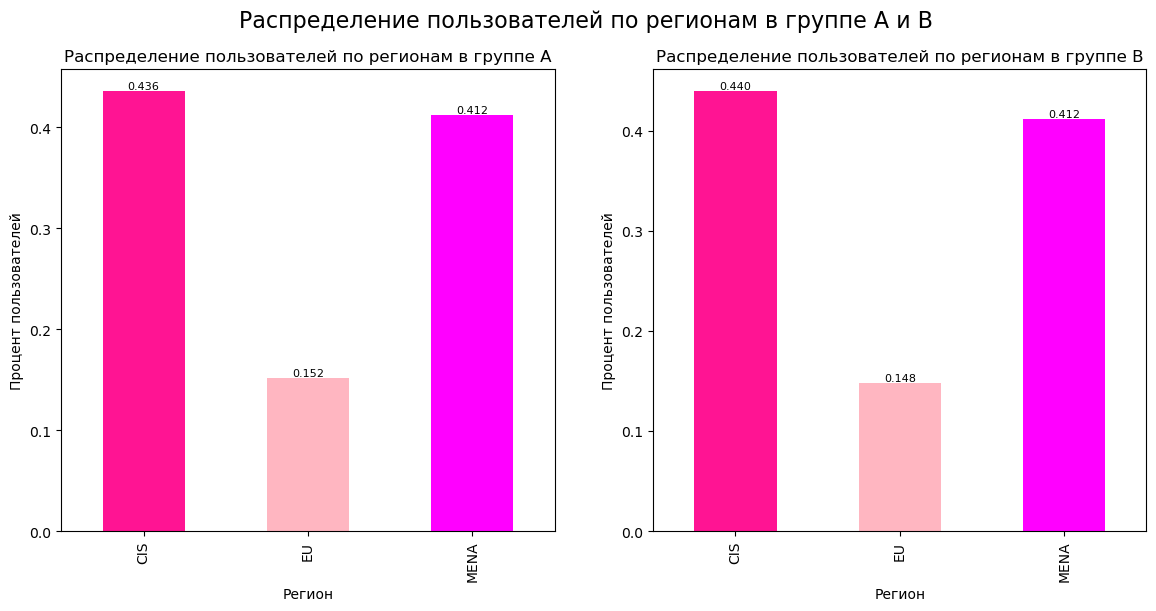

In [32]:
#задаем размер графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#устанавливаем цвета для данных 
colors = ['deeppink','lightpink', 'magenta']

#формируем график
for idx, (name, data) in enumerate(group_region.groupby('test_group')):
    ax = axes[idx]
    data.plot(kind = 'bar', x = 'region', y = 'share', ax = ax, color = colors)
    ax.set_title(f'Распределение пользователей по регионам в группе {name}')
    ax.set_xlabel('Регион',fontsize=10)
    ax.set_ylabel('Процент пользователей',fontsize=10)
    ax.legend_.remove()
    
    # Добавляем подписи
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
fig.suptitle ('Распределение пользователей по регионам в группе A и B', fontsize=16)
plt.show()

#### 3.5. Вывод после проверки A/B-теста



- размер выборок: выборки А и В близки по численности, различия составляют менее 0.7448%, что гарантирует их сопоставимость для тестирования;
- независимость выборок: нет пересечения пользователей между группами, выборки независимы;
- распределение по категориям: распределение пользователей по регионам и устройствам однородно, малые отклонения допускаются и не искажают результаты.

Поэтому, представленная контрольная и тестовая группы могут использоваться для проведения А/В - тестирования с целью выявления того повлияет ли внедрение новых алгоритмов рекомендации в приложение на пользователей или нет.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики


In [33]:
try: 
    sessions_test = pd.read_csv('C:/Users/Ирэн/Documents/Обучение/Data Analis_Яндекс_Практикум/Дата_сеты/AB-тестирование/sessions_project_test.csv', sep = ',')
except FileNotFoundError:
    sessions_test = pd.read_csv('/datasets/sessions_project_test.csv', sep = ',')

In [34]:
sessions_test['good_session'] = (sessions_test['page_counter']>=4).astype(int)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- рассчитать количество уникальных сессий для каждого дня и обеих тестовых групп;

- проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимы, для этого будем использовать статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- интерпретация результатов.

In [35]:
sessions_test_group = sessions_test.groupby(['session_date','test_group'])['session_id'].nunique().reset_index()
sessions_test_group.columns = ['date', 'test_group', 'unique_sessions']
sessions_test_group.head()

,date,test_group,unique_sessions
0,2025-10-14,A,1502
1,2025-10-14,B,1628
2,2025-10-15,A,2235
3,2025-10-15,B,2283
4,2025-10-16,A,3280


Для оценки сопоставимости двух выборок следует использовать t-тест, для оценки наличия или отсутствия различий в количестве уникальных дневных сессий в выборках. Поэтому, следует сформировать нулевую и альтернативную гипотезы, которые звучат так:
 - Нулевая гипотеза (Н0): количество уникальных сессий в тестовой и контрольной выборке не различимы;
 - Альтернативная гипотеза (Н1): количество уникальных сессий в тестовой и контрольной выборке различимы


In [36]:
##сформировали необходимые метрики для теста
metric_a= sessions_test_group[sessions_test_group['test_group']=='A']['unique_sessions']
metric_b = sessions_test_group[sessions_test_group['test_group']=='B']['unique_sessions']

#уровень значимости
alpha = 0.05

#t-тест 
t_statistic, p_value = ttest_ind(metric_a,
                                      metric_b,
                                      alternative='two-sided')

print(f'p-value теста Стьюдента ={round(p_value,3)}')

if p_value > alpha:
    print("Нулевая гипотеза подтверждена ! Количество уникальных сессий в тестовой и контрольной выборке не различимы")
else:
    print("Нулевая гипотеза опровергнута!Принимаем альтернативную гипотезу! Количество уникальных сессий в тестовой и контрольной выборке различимы")


p-value теста Стьюдента =0.938
Нулевая гипотеза подтверждена ! Количество уникальных сессий в тестовой и контрольной выборке не различимы


Таким образом, `p-value` в результате проведения `t-теста` оказался равным `0,937`, что больше допустимого уровня значимости, то есть различия между количеством уникальных дневных сессий в двух группах не являются статистически значимыми. Это значит, что обе группы можно считать сопоставимыми.

#### 4.3. Сравнение доли успешных сессий

Проведем оценку ключевой метрики для обеих групп участвующих в тестировании. 

In [37]:
## посчитаем размер группы А
n_a = sessions_test[ sessions_test.test_group=='A'].shape[0]

## посчитаем размер группы B
n_b = sessions_test[ sessions_test.test_group=='B'].shape[0]

##посчитаем количество успешных сессий для группы А
m_a = sessions_test[(sessions_test.test_group=='A')&(sessions_test.good_session==1)].shape[0]

##посчитаем количество успешных сессий для группы B
m_b = sessions_test[(sessions_test.test_group=='B')&(sessions_test.good_session==1)].shape[0]

## считаем долю успешных сессий
p_a, p_b = m_a/n_a, m_b/n_b

print(f'Доля успешных сессий в группе А = {p_a:.4f}')
print(f'Доля успешных сессий в группе B = {p_b:.4f}')
print()
print(f'Разница между группами А и В = {p_b-p_a:.4f}')


Доля успешных сессий в группе А = 0.3077
Доля успешных сессий в группе B = 0.3183

Разница между группами А и В = 0.0106


Можно отметить, что доля успешных сессий в обеих группах практически равна и имеет незначительное различие. Однако только на основе данных показателей мы не можем определить ведет ли изменение алгоритмов к росту доли успешных сессий или же нет. Для получения более точного ответа следует провести оценку метрики с использованием статистического теста. 

#### 4.4. Оценка статистической значимости изменения ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо ответить на вопрос: является ли это изменение статистически значимым. Для этого необходимо:

- используя статистический тест, рассчитать, является ли изменение в метрике доли успешных сессий статистически значимым;

- провести оценку результатов теста и интерпретировать  `p-value`.

Напомним, нашу нулевую и альтернативную гипотезу сформированные исходя из первоначальных требований:

`Нулевая гипотеза (H₀)`: новый алгоритм рекомендаций не меняет долю успешных сессий (pB <= pA).

`Альтернативная гипотеза (H₁)`: новый алгоритм увеличивает долю успешных сессий (pB > pA).

Для оценки значимости изменения метрики для подтверждения одной из гипотез нам необходимо провести статистический тест. При этом так как ключевая метрика является относительной метрикой, то целесообразно за основу взять статистический тест Z -  пропорции.

Перед тем как приступить к проведению статистического теста Z- пропорции следует провести доп. исследование данных о достаточности их количества.



In [38]:
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных не выполняется!')

Предпосылка о достаточном количестве данных выполняется!


In [39]:
alpha = .05

stat_ztest, p_value_ztest = proportions_ztest([m_a,m_b],
                                              [n_a,n_b],
                                              alternative='smaller')
print(f'p-value теста Z-пропорции = {round(p_value_ztest,5)}')

if p_value_ztest>alpha:
    print('Доли успешных сессий группы A и B равны')
    print()
    print('Интерпретация: использование новых алгоритмов рекомендаций не увеличит долю успешных сессий')
else:
    print('Доли успешных сессий группы A и B неравны')
    print('Интерпретация: использование новых алгоритмов рекомендаций увеличит долю успешных сессий')

p-value теста Z-пропорции = 0.00016
Доли успешных сессий группы A и B неравны
Интерпретация: использование новых алгоритмов рекомендаций увеличит долю успешных сессий


#### 4.5. Вывод по результатам A/B-эксперимента

- в тесте было задействовано `1477 ` уникальных пользователя в `группе А ` и `1466 ` уникальных пользователя в `группе B`, тестирование длилось  `с 2025-10-14 по 2025-11-02 `, то есть в течение `20 дней `;
- исследование подтвердило независимость и случайность выборок, что позволило признать их репрезентативными;
- проверка корректности результатов теста с использованием t-теста показала, что `p-value теста Стьюдента = 0.938 `, то есть то есть различия между средними значениями уникальных дневных сессий в двух группах не являются статистически значимыми. Это значит, что обе группы можно считать сопоставимыми;
- использование нового алгоритма увеличило долю успешных сессий на 0.0106 (до 0.3183) в группе B;
- тест Z-пропорций выявил статистическую значимость изменений p-value=0.00016 при α =0.05. Гипотеза о росте успешных сессий подтвердилась.
Таким образом, оценивая результаты проведенного тестирования мы можем говорить, что компания может реализовать механизмы по внедрению новых алгоритмов рекомендаций, так как это позволит повысить долю успешных сессий приложения.
